This notebook follows on from the learning rate experiments, the spatial cv investigation, and also after the work in the SLX Proof of Concept notebook established slx as the best choice for a spatially aware model. That notebook is a foundation for this one (or this one extends the previous ones). 

So far, we have demonstrated the presence of overfitting in the original models and tried to both mitigate and quantify it. The expansion of the sample to other cities was successful, which is why this notebook will now compare the ridge and slx models using the most recent multi city data. This expansion has been shown to reduce but not eliminate a gap between test and train r2 (used to quantify overfitting). We have also implemented spatial cross validation (using clusters of lsoas to hold out) and shown that the model does have a dependency on spatial proximity. That is, it fail if asked to predict the score of an lsoa with no nearby lsoas in the training data. From those findings, we will use spatial cv with k=10 as the standard evaluation method in this notebook. 

In this notebook, i am specifically interested in how slx and ridge compare on specific feature sets. I don't think that a finding from comparing the two models on any configuration of features will hold generally. This is for a few reasons:
- I think the dimensionality reduction method might matter. If the remaining componants are less interpretable, perhaps the spatial information extracted is less useful. 
- slx will become susceptable to the curse of dimensionality much sooner than ridge, since it essentially doubles the feature space. There will be a trade off between adding more signal through new features and resisting too many features, and that balance point will be different for the two models.
- we already have a way of including some spatially aware features without slx - the osm features can include a buffer that extracts information within a certain distance of the lsoa.

# Ridge vs SLX

compare the two models using the same evalutation, and same configuration of features (engineered_rates_v2). We will use the alpha for ridge found in previous values, but sweep for the best alpha for slx (extra features means there could be a new best alpha)

In [1]:
import numpy as np
import polars as pl
import pandas as pd
from functools import partial
from project_paths import paths, project_root
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, GroupKFold
from imd_features.config import FeatureSetConfig
from imd_features.process import create_feature_set
from imd_features.spatial_utils import fetch_spatial_support_data
from imd_features.cross_validate import cross_validate, extend_slx

In [2]:
engineered_features_path = project_root / "data" / "output" / "engineered_rates_v2_c3ad0464.parquet"

df_features = pl.read_parquet(engineered_features_path)
target_df = pl.read_parquet(paths.reference)
combined = df_features.join(target_df, on="lsoa_code", how="inner")

feature_cols = [c for c in df_features.columns if c not in ("lsoa_code", "score", "rank")]
lsoa_codes = combined.get_column("lsoa_code").to_list()
X = combined.select(feature_cols).to_numpy()
y = combined.select("score").to_numpy().ravel()

print(X.shape, y.shape, len(feature_cols))

(268, 54) (268,) 54


In [3]:
W, groups, aligned_codes = fetch_spatial_support_data(
    lsoa_codes=lsoa_codes,
    boundaries_path=paths.polygons,
    lookup_path=paths.lads,
    n_clusters_per_city=10,
)

spatial_cv = GroupKFold(n_splits=5)
slx_fn = partial(extend_slx, W=W)

In [4]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]

ridge_results = {}
slx_results = {}

for alpha in alphas:
    model = Ridge(alpha=alpha)

    ridge_results[alpha] = cross_validate(X, y, model, spatial_cv, groups=groups)
    slx_results[alpha] = cross_validate(X, y, model, spatial_cv, groups=groups, extend_func=slx_fn)

    print(f"alpha: {alpha}\n Ridge R2: {ridge_results[alpha]['r2_mean']}\n SLX R2:{slx_results[alpha]['r2_mean']}")

alpha: 0.001
 Ridge R2: 0.925290773503211
 SLX R2:0.8200331243240855
alpha: 0.01
 Ridge R2: 0.9257602779491918
 SLX R2:0.830691891646383
alpha: 0.1
 Ridge R2: 0.9261528825404968
 SLX R2:0.8588674916129868
alpha: 1
 Ridge R2: 0.9260993956849255
 SLX R2:0.8994028708284031
alpha: 10
 Ridge R2: 0.9150907386191488
 SLX R2:0.9032405291610983
alpha: 100
 Ridge R2: 0.8134745200593857
 SLX R2:0.799955324564667
alpha: 500
 Ridge R2: 0.6026788933678696
 SLX R2:0.5648735885268414
alpha: 1000
 Ridge R2: 0.4349947730764761
 SLX R2:0.3991733938316921


In [5]:
rows = []
for alpha in alphas:
    rows.append({
        "model": "ridge",
        "alpha": alpha,
        "r2_mean": ridge_results[alpha]["r2_mean"],
        "r2_std": ridge_results[alpha]["r2_std"],
        "rmse_mean": ridge_results[alpha]["rmse_mean"],
        "spearman_mean": ridge_results[alpha]["spearman_mean"],
    })
    rows.append({
        "model": "slx",
        "alpha": alpha,
        "r2_mean": slx_results[alpha]["r2_mean"],
        "r2_std": slx_results[alpha]["r2_std"],
        "rmse_mean": slx_results[alpha]["rmse_mean"],
        "spearman_mean": slx_results[alpha]["spearman_mean"],
    })

summary = pd.DataFrame(rows)
summary

,model,alpha,r2_mean,r2_std,rmse_mean,spearman_mean
0,ridge,0.001,0.925291,0.028539,3.613109,0.923579
1,slx,0.001,0.820033,0.033921,5.831034,0.850458
2,ridge,0.010,0.925760,0.028478,3.602396,0.923953
3,slx,0.010,0.830692,0.040617,5.591898,0.859081
4,ridge,0.100,0.926153,0.027536,3.607689,0.925437
5,slx,0.100,0.858867,0.025849,5.145832,0.876108
6,ridge,1.000,0.926099,0.022935,3.673788,0.927302
7,slx,1.000,0.899403,0.022256,4.431498,0.908688
8,ridge,10.000,0.915091,0.020161,4.038508,0.934973
9,slx,10.000,0.903241,0.021893,4.360622,0.920659


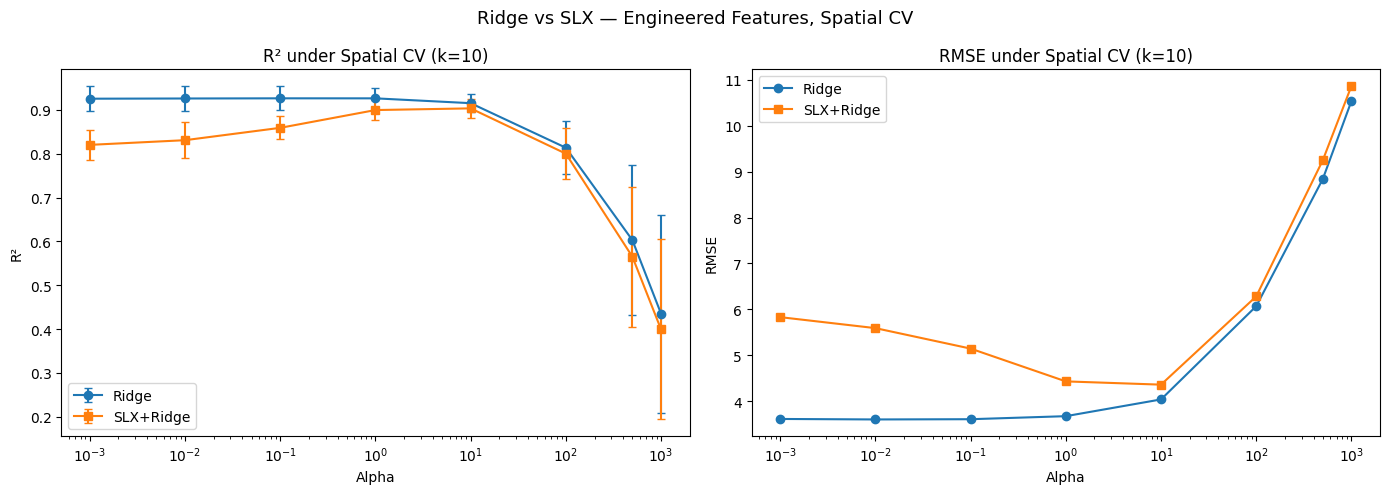

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ridge_r2 = [ridge_results[a]["r2_mean"] for a in alphas]
ridge_r2_std = [ridge_results[a]["r2_std"] for a in alphas]
slx_r2 = [slx_results[a]["r2_mean"] for a in alphas]
slx_r2_std = [slx_results[a]["r2_std"] for a in alphas]

axes[0].errorbar(alphas, ridge_r2, yerr=ridge_r2_std, label="Ridge", marker="o", capsize=3)
axes[0].errorbar(alphas, slx_r2, yerr=slx_r2_std, label="SLX+Ridge", marker="s", capsize=3)
axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("R²")
axes[0].set_title("R² under Spatial CV (k=10)")
axes[0].legend()

ridge_rmse = [ridge_results[a]["rmse_mean"] for a in alphas]
slx_rmse = [slx_results[a]["rmse_mean"] for a in alphas]

axes[1].plot(alphas, ridge_rmse, label="Ridge", marker="o")
axes[1].plot(alphas, slx_rmse, label="SLX+Ridge", marker="s")
axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("RMSE")
axes[1].set_title("RMSE under Spatial CV (k=10)")
axes[1].legend()

fig.suptitle("Ridge vs SLX — Engineered Features, Spatial CV", fontsize=13)
fig.tight_layout()
plt.show()

for this config of features, it seems that ridge actually always outperforms slx. Im not completely suprised - we know that htis feature config contains several features extracted from OSM at a buffer of 1000 metres. This means that the slx is double extracting spatial information, which is likely to provide more noise than signal imo. 

Next would be to repeat on a feature set that contains only features with a buffer of 0.